# Scene Selection and Download: NDWI & Water Masks

This script automates the selection, retrieval, and storage of satellite imagery for surface water analysis in Northern Manitoba. It is designed to download and preprocess the raw data needed for multi-temporal NDWI (Normalized Difference Water Index) and water mask analyses.

### Workflow Overview

1. **Define Area of Interest (AOI)**
   - Load AOI polygon(s) from GeoJSON or KML files.
   - Validate and visualize AOI boundaries.

2. **Search Satellite Collections**
   - Sentinel-2 Level-2A (`S2_L2A`) for 10–20m resolution imagery.
   - Landsat-8 (`L8`) for 30m resolution imagery.
   - Filter scenes by:
     - Temporal extent (e.g., summer months)
     - Cloud cover
     - Spatial overlap with AOI

3. **Download and Store Scenes**
   - Retrieve raw spectral bands required for NDWI calculation.
   - Save as GeoTIFFs in organized folder structure:
     ```
     data/
        raw/
           sentinel2/
           landsat8/
     ```
   - Optionally unzip or stack downloaded scenes.

4. **Generate Metadata**
   - Export a CSV of all downloaded scenes for bookkeeping.
   - Include scene IDs, acquisition dates, footprint geometries, and band information.

### Outputs
- Water mask GeoTIFFs (if available from source or generated after NDWI calculation).
- CSV inventory of downloaded scenes for reproducibility.

### Usage
1. Update AOI file paths and temporal filters as needed.
2. Run the script; progress is displayed for each year and sensor.
3. Verify downloaded files and footprints before running the main analysis pipeline.


In [30]:
import openeo
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from shapely.geometry import Point
from shapely.ops import transform
import rasterio
import tempfile
import warnings
from rasterio.transform import from_origin
from openeo.rest.auth.config import RefreshTokenStore

# Remove all stored refresh tokens
# RefreshTokenStore().remove()

In [31]:
# -----------------------------
# PARAMETERS
# -----------------------------
AOI_PATH = "../data/aoi/2025_aoi.geojson"
OUTPUT_DIR = "../data/results/"
RAW_DIR = "../data/raw/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)

# Define year ranges to process
YEARS = {
    "2016": ["2016-06-01", "2016-08-31"],
    "2017": ["2017-06-01", "2017-08-31"],
    "2018": ["2018-06-01", "2018-08-31"],
    "2019": ["2019-06-01", "2019-08-31"],
    "2020": ["2020-06-01", "2020-08-31"],
    "2021": ["2021-06-01", "2021-08-31"]
}

# extract year from start date
# YEAR = START_DATE[:4]

# -----------------------------
# SENSORS CONFIG (automatic collection switch)
# -----------------------------
SENSORS = {
    "Sentinel-2": {
        "id": "SENTINEL2_L1C",
        "rgb_bands": ["B04","B03","B02"],
        "ndwi_bands": ["B03","B08"],
        "cloud_cover_max": 20  # relaxed for northern areas
    },
    "Landsat-8": {
        "id": "LANDSAT8-9_L2",
        "rgb_bands": ["B04","B03","B02"],
        "ndwi_bands": ["B03","B05"],
        "cloud_cover_max": 40
    }
}

# -----------------------------
# CONNECT TO OPENEO BACKEND
# -----------------------------
# Remove all stored refresh tokens
connection = openeo.connect("openeo.vito.be").authenticate_oidc()
print("Authenticated with openEO VITO backend")

Authenticated using refresh token.
Authenticated with openEO VITO backend


In [32]:
# -----------------------------
# LOAD AOI
# -----------------------------
aoi = gpd.read_file(AOI_PATH)
geom_type = aoi.geometry.iloc[0].geom_type
if geom_type == "Point":
    print("AOI is a Point; buffering to create a Polygon...")
    aoi.geometry = aoi.geometry.buffer(0.05)  # ~5 km buffer
aoi_geom = aoi.geometry.values[0].__geo_interface__

AOI is a Point; buffering to create a Polygon...


In [33]:
# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def find_best_scene(sensor, bands, start_date, end_date):
    return connection.load_collection(
        sensor["id"],
        spatial_extent=aoi_geom,
        temporal_extent=[start_date, end_date],
        bands=bands,
        max_cloud_cover=sensor["cloud_cover_max"]
    )

def download_array(coll):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".tif", delete=False).name
    coll.download(tmp_file)
    with rasterio.open(tmp_file) as src:
        arr = src.read()  # shape: bands, rows, cols
        transform = src.transform
        crs = src.crs
    try:
        os.remove(tmp_file)
    except Exception:
        pass
    return np.transpose(arr, (1,2,0)), transform, crs  # HWC, transform, CRS

def apply_data_mask(rgb_arr, mask_arr):
    rgb = rgb_arr.astype(float).copy()
    if mask_arr is None:
        return rgb
    mask_bool = (mask_arr > 0)
    if mask_bool.shape != rgb.shape[:2]:
        return rgb
    rgb[~mask_bool] = np.nan
    return rgb

def linear_percent_stretch(rgb, lower_percent=2, upper_percent=98):
    out = np.empty_like(rgb, dtype=float)
    for i in range(rgb.shape[2]):
        band = rgb[:,:,i]
        low, high = np.nanpercentile(band, [lower_percent, upper_percent])
        if np.isfinite(low) and np.isfinite(high) and (high - low) > 1e-6:
            out[:,:,i] = np.clip((band - low) / (high - low), 0, 1)
        else:
            mx = np.nanmax(band)
            if mx > 0:
                out[:,:,i] = np.clip(band / mx, 0, 1)
            else:
                out[:,:,i] = band
    return out

def gamma_correction(rgb, gamma=1.2):
    if gamma is None or gamma == 1.0:
        return rgb
    rgb = np.clip(rgb, 0, 1)
    return np.power(rgb, 1.0/gamma)

def prepare_rgb_for_display(rgb_arr, data_mask=None, lower_percent=2, upper_percent=98, gamma=1.2):
    rgb = apply_data_mask(rgb_arr, data_mask)
    stretched = linear_percent_stretch(rgb, lower_percent, upper_percent)
    corrected = gamma_correction(stretched, gamma=gamma)
    return np.nan_to_num(corrected, nan=0.0)

def try_download_datamask(sensor, start_date, end_date):
    try:
        mask_coll = connection.load_collection(
            sensor["id"],
            spatial_extent=aoi_geom,
            temporal_extent=[start_date, end_date],
            bands=["dataMask"],
            max_cloud_cover=sensor["cloud_cover_max"]
        )
        mask_arr, _, _ = download_array(mask_coll)
        if mask_arr.ndim == 3 and mask_arr.shape[2] >= 1:
            return mask_arr[:,:,0]
        else:
            return None
    except Exception as e:
        warnings.warn(f"dataMask download failed for {sensor['id']}: {e}")
        return None

def save_raster(arr, sensor_name, year, suffix, transform, crs, dtype=None, out_dir=None):
    if arr is None:
        print(f"No data to save for {sensor_name} {suffix} {year}")
        return
    if dtype is None:
        dtype = arr.dtype
    height, width = arr.shape[:2]

    # Use OUTPUT_DIR if out_dir is not specified
    save_dir = out_dir if out_dir else OUTPUT_DIR
    os.makedirs(save_dir, exist_ok=True)

    out_path = os.path.join(save_dir, f"{sensor_name.lower().replace('-','')}_{suffix}_{year}.tif")
    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(arr.astype(dtype), 1)

    print(f"Saved {out_path}")

In [34]:
def safe_imshow(ax, img, title="", cmap=None, colorbar=False):
    ax.set_title(title)

    if img is None:
        ax.text(0.5, 0.5, "No data",
                ha="center", va="center",
                transform=ax.transAxes)
        ax.axis("off")
        return

    im = ax.imshow(img, cmap=cmap)
    ax.axis("off")

    if colorbar:
        import matplotlib.pyplot as plt
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


=== Processing year 2017 (2017-06-01 → 2017-08-31) ===

Processing Sentinel-2...
Saved ../data/results/sentinel2/sentinel2_ndwi_2017.tif
Saved ../data/results/sentinel2/sentinel2_watermask_2017.tif
Processing Landsat-8...
Saved ../data/results/landsat8/landsat8_ndwi_2017.tif
Saved ../data/results/landsat8/landsat8_watermask_2017.tif


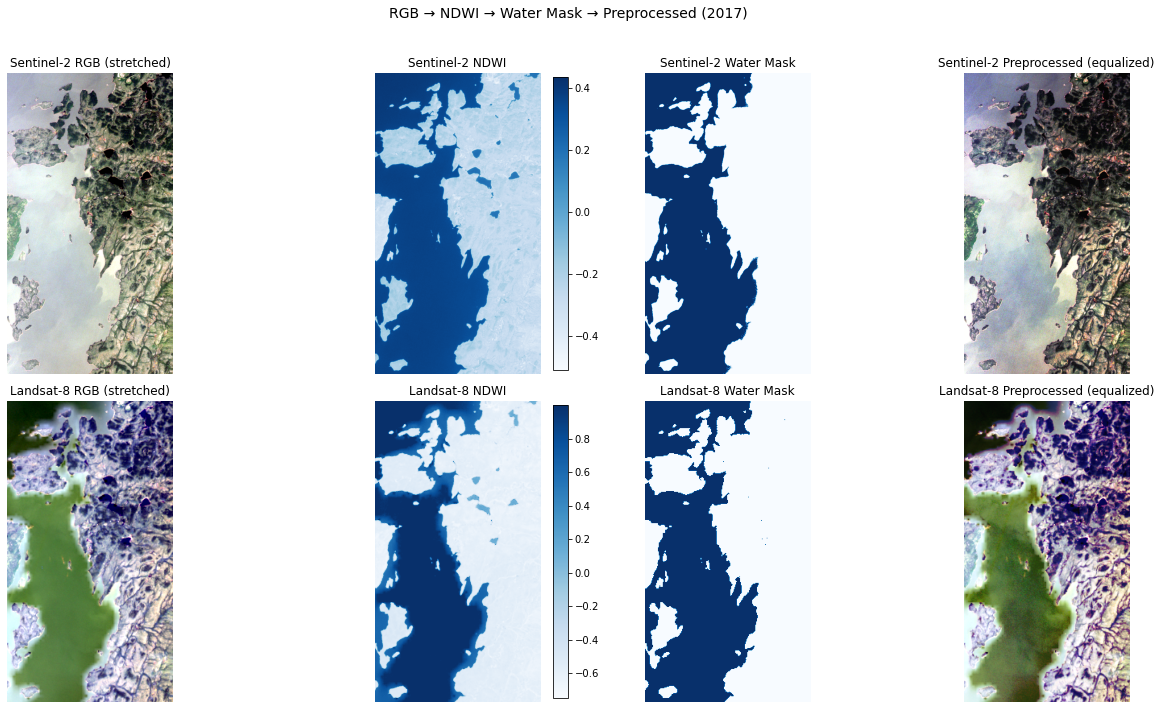

<Figure size 432x288 with 0 Axes>


=== Processing year 2018 (2018-06-01 → 2018-08-31) ===

Processing Sentinel-2...
Saved ../data/results/sentinel2/sentinel2_ndwi_2018.tif
Saved ../data/results/sentinel2/sentinel2_watermask_2018.tif
Processing Landsat-8...
Saved ../data/results/landsat8/landsat8_ndwi_2018.tif
Saved ../data/results/landsat8/landsat8_watermask_2018.tif


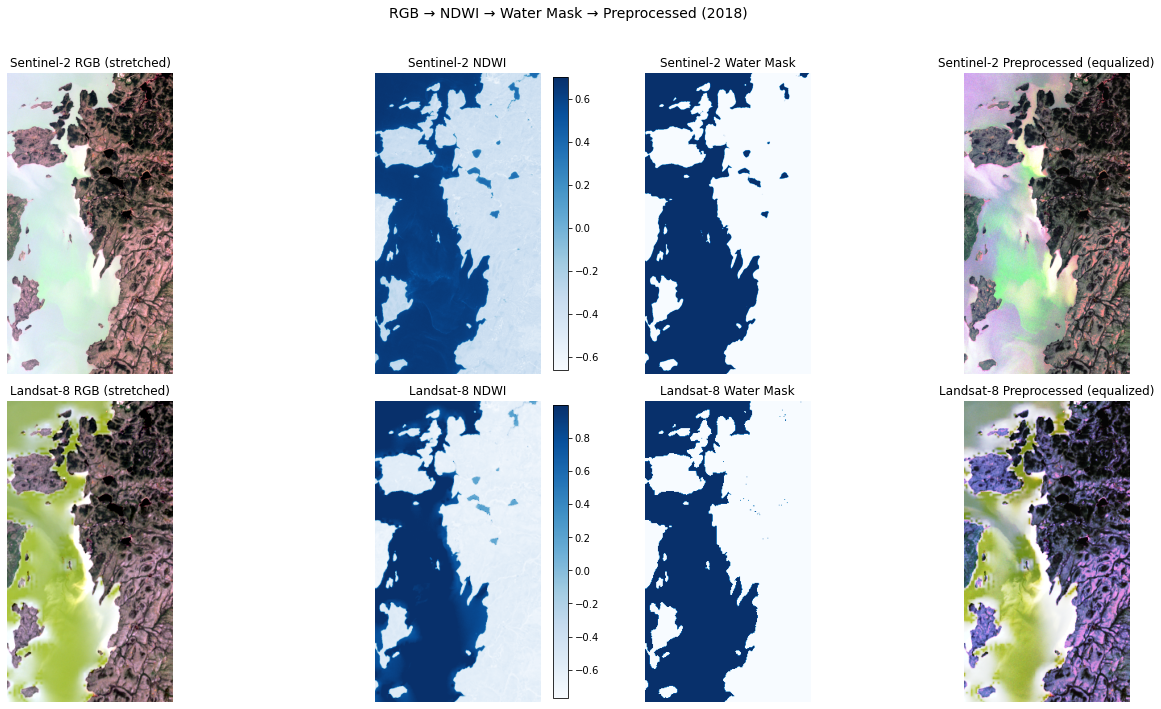

<Figure size 432x288 with 0 Axes>


=== Processing year 2021 (2021-06-01 → 2021-08-31) ===

Processing Sentinel-2...
Saved ../data/results/sentinel2/sentinel2_ndwi_2021.tif
Saved ../data/results/sentinel2/sentinel2_watermask_2021.tif
Processing Landsat-8...
Saved ../data/results/landsat8/landsat8_ndwi_2021.tif
Saved ../data/results/landsat8/landsat8_watermask_2021.tif


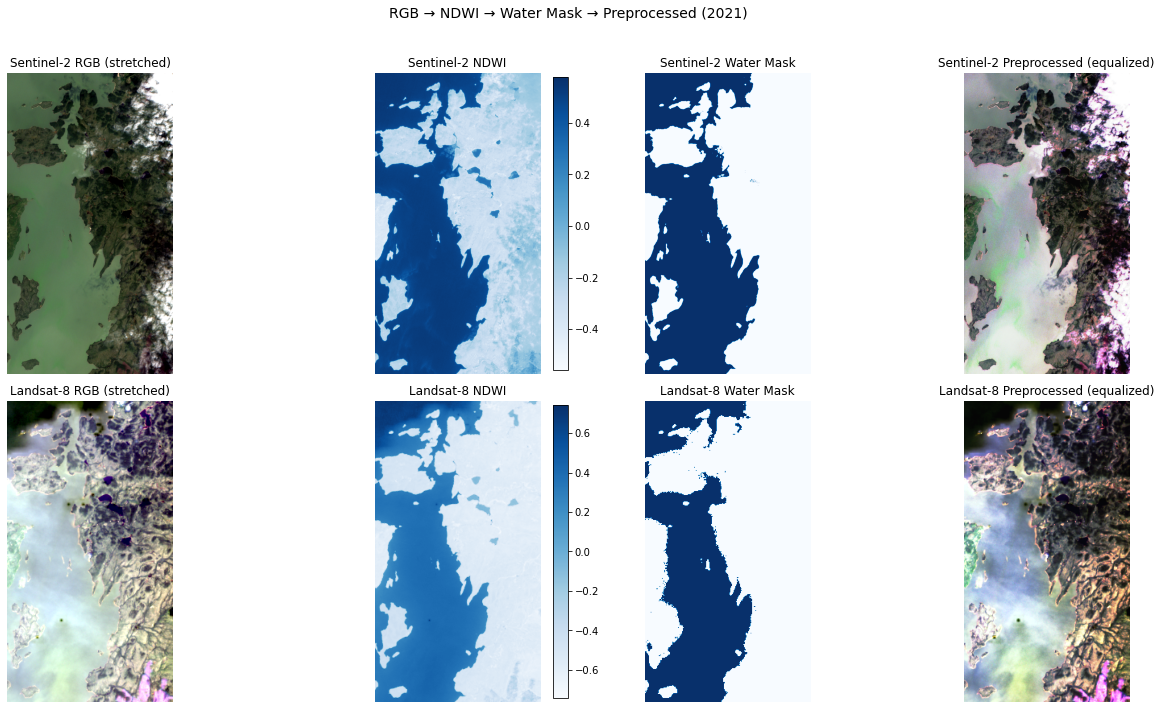

<Figure size 432x288 with 0 Axes>

In [35]:
# -----------------------------
# MAIN PROCESS LOOP
# -----------------------------
for year, (start_date, end_date) in YEARS.items():
    print(f"\n=== Processing year {year} ({start_date} → {end_date}) ===\n")
    results = {}
    for name, sensor in SENSORS.items():
        print(f"Processing {name}...")
        # -----------------------------
        # Create sensor-specific folder
        # -----------------------------
        sensor_folder = os.path.join(OUTPUT_DIR, name.lower().replace('-', ''))
        os.makedirs(sensor_folder, exist_ok=True)

        data_mask = try_download_datamask(sensor, start_date, end_date)

        # RGB
        try:
            rgb_coll = find_best_scene(sensor, sensor["rgb_bands"], start_date, end_date)
            rgb_img, _, _ = download_array(rgb_coll)
            rgb_display = prepare_rgb_for_display(rgb_img, data_mask=data_mask,
                                                  lower_percent=2, upper_percent=98, gamma=1.2)
        except Exception as e:
            warnings.warn(f"Failed to download RGB for {name}: {e}")
            rgb_img, rgb_display = None, None

        # NDWI + water mask
        try:
            ndwi_coll = find_best_scene(sensor, sensor["ndwi_bands"], start_date, end_date)
            ndwi_bands, transform, crs = download_array(ndwi_coll)
            if ndwi_bands.ndim == 3 and ndwi_bands.shape[2] >= 2:
                green = ndwi_bands[:,:,0].astype(float)
                nir   = ndwi_bands[:,:,1].astype(float)
                ndwi_arr = (green - nir) / (green + nir + 1e-10)
                water_mask = (ndwi_arr > 0.3).astype(np.uint8)
            else:
                raise ValueError("Downloaded NDWI bands not shape HxWx2")
        except Exception as e:
            warnings.warn(f"Failed to compute NDWI for {name}: {e}")
            ndwi_arr, water_mask = None, None
            transform, crs = None, "EPSG:4326"

        results[name] = {
            "RGB_raw": rgb_img,
            "RGB_display": rgb_display,
            "NDWI": ndwi_arr,
            "Water": water_mask,
            "transform": transform,
            "crs": crs
        }
        
        # Save NDWI & Water mask
        sensor_folder = os.path.join(RAW_DIR, name.lower().replace('-', ''))
        os.makedirs(sensor_folder, exist_ok=True)

        save_raster(ndwi_arr, name, year, "ndwi", transform, crs, dtype=np.float32, out_dir=sensor_folder)
        save_raster(water_mask, name, year, "watermask", transform, crs, dtype=np.uint8, out_dir=sensor_folder)

    # OPTIONAL: plot summary
    try:
        fig, axes = plt.subplots(2, 4, figsize=(18, 10))
        sensor_order = ["Sentinel-2", "Landsat-8"]

        for r, sname in enumerate(sensor_order):
            res = results.get(sname, {})
            safe_imshow(axes[r,0], res.get("RGB_display"), title=f"{sname} RGB (stretched)")
            safe_imshow(axes[r,1], res.get("NDWI"), cmap="Blues", title=f"{sname} NDWI", colorbar=True)
            safe_imshow(axes[r,2], res.get("Water"), cmap="Blues", title=f"{sname} Water Mask")

            preproc = None
            if res.get("RGB_raw") is not None:
                raw = res["RGB_raw"].astype(float)
                he = np.empty_like(raw, dtype=float)
                for i in range(raw.shape[2]):
                    band = raw[:,:,i]
                    stretched = linear_percent_stretch(band[:,:,None], 2, 98)[:,:,0]
                    hist, bins = np.histogram(stretched.flatten(), bins=256, range=(0,1))
                    cdf = hist.cumsum() / hist.cumsum()[-1]
                    he[:,:,i] = np.interp(stretched.flatten(), bins[:-1], cdf).reshape(stretched.shape)
                preproc = np.nan_to_num(he)

            safe_imshow(axes[r,3], preproc, title=f"{sname} Preprocessed (equalized)")

        plt.suptitle(f"RGB → NDWI → Water Mask → Preprocessed ({year})", fontsize=14)
        plt.tight_layout(rect=[0,0,1,0.96])
        plt.savefig(os.path.join(OUTPUT_DIR, f"comparison_{year}.png"), dpi=300)
        plt.show()
    except Exception as e:
        warnings.warn(f"Plotting failed for year {year}: {e}")

    plt.suptitle(f"RGB → NDWI → Water Mask → Preprocessed ({year})", fontsize=14)
    fig.savefig(
        os.path.join(OUTPUT_DIR, f"comparison_{year}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()